In [1]:
import numpy as np
from scipy.integrate import solve_ivp as sp_solve_ivp
from scipy.integrate import odeint
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from typing import List
device = 'cpu'
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from ftnode.utils import set_global_seed
from ftnode.node import (
    FTNODE, FeluSigmoidMLP, GeluSigmoidMLP,)

import torchode
import numpy as np

seed = 1234
set_global_seed(seed)

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
f = FeluSigmoidMLP(dims=[2,20,20,20,2],lower_bound=-1, upper_bound=-0.1)
g = GeluSigmoidMLP(dims=[4,20,20,20,2],lower_bound=0, upper_bound=1)
model = FTNODE(f,g).to(device)

model_path = "../best_model-20-20-20.pth"

model.load_state_dict(torch.load(model_path))

g = model.g
g.eval()

GeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=4, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=2, bias=True)
    )
  )
)

In [3]:
## Define system 
gamma1 = 50
def sigmoid(x,gamma=gamma1):
    return 1 / (1+np.exp(-gamma*x))

eps = 0.02
q1, q2 = (0.08, 0.04)
b1 = 1-eps
b2 = 1-eps

def c1_in(x):
    return q1*(1-sigmoid(x-b1))

def c2_in(y):
    return q1*(1-sigmoid(y-b2))

def c1_out(y):
    return q2*(1-sigmoid(y-b2))

def c2_out(y):
    return q2

def two_tank_system(t,x,u):
    x1, x2 = x
    p, v = u
    x1= np.maximum(x1,0)
    x2 = np.maximum(x2,0)
    dx1dt = c1_in(x1)*(1-v)*p-c1_out(x2)*np.sqrt(x1)
    dx2dt = c2_in(x2)*v*p +c1_out(x2)*np.sqrt(x1)-q2*np.sqrt(x2)
    return np.hstack([dx1dt,dx2dt])


p_vals = np.linspace(0,1,101)
v_vals = np.linspace(0,1,101)

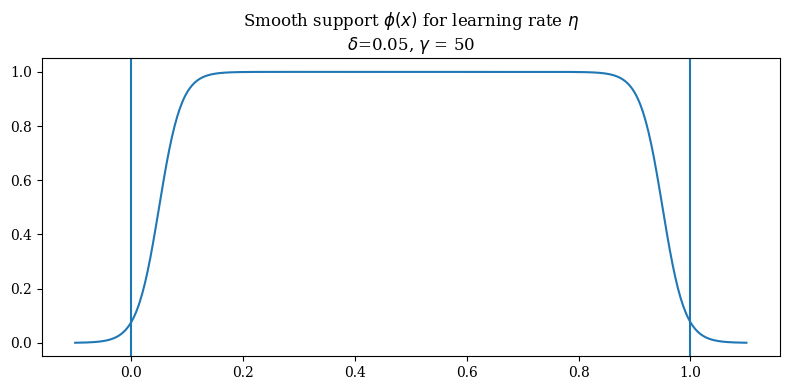

In [4]:
def H(x,gamma):
    return 1 / (1+np.exp(-gamma*x))

def phi(x,a,b,delta,gamma):
    return H(x-(a+delta),gamma) - H(x-(b-delta),gamma)

delta=0.05
a=0
b=1
gamma=50

xs = np.linspace(-0.1,1.1,501)
plt.figure(figsize=(8,4))
plt.plot(xs,phi(xs,a=a,b=b,delta=delta,gamma=gamma))
plt.axvline(0)
plt.axvline(1)
plt.title(
    r"Smooth support $\phi(x)$ for learning rate $\eta$"
    "\n"
    rf"$\delta$={delta:.2f}, $\gamma$ = {gamma}"
)
plt.tight_layout()
plt.show()


In [5]:
def R(u,x,k, x_target):
    for _ in range(k):
        x = g(x, u)
    return x - x_target

def u_prime(u,x,x_target,eta,k):
    phi_u = phi(u,a,b,delta,gamma)
    u = torch.tensor(u,dtype=torch.float32, requires_grad=True)
    x = torch.tensor(x,dtype=torch.float32, requires_grad=False)
    x_target = torch.tensor(x_target,dtype=torch.float32, requires_grad=False)
    resid = torch.sum(R(u,x,k,x_target)**2)
    resid.backward()

    grad = u.grad.numpy()
    
    return -eta*grad*phi_u

# test
def two_tank_system_control(t,xu, x_target,eta,k):
    x = xu[:2]
    u = xu[2:]
    dx1dt, dx2dt = two_tank_system(t,x,u)
    dpdt, dvdt = u_prime(u,x,x_target,eta,k)

    return np.hstack([dx1dt,dx2dt,dpdt,dvdt])

# noise
def two_tank_noise(x, scale=0.01):
    sig1 = scale * np.sqrt(abs(x[0]))
    sig2 = scale * np.sqrt(abs(x[1]))
    return np.diag([sig1, sig2])

# drift term
def make_drift(x_target, eta,k):
    def drift(xu,t):
        x = xu[:2]
        u = xu[2:]
        dx1dt, dx2dt = two_tank_system(t,x,u)
        dpdt, dvdt = u_prime(u,x,x_target,eta,k)

        return np.hstack([dx1dt,dx2dt,dpdt,dvdt])
    return drift

# difussion term
def make_diffusion(scale):
    def diffusion(xu, t):
        x = xu[:2]
        Gx = two_tank_noise(x,scale)
        G = np.zeros((4, 2))
        G[:2, :2] = Gx
        return G
    return diffusion

In [6]:
seed = 1
rng = np.random.default_rng(seed=seed)


# k=1
# scale = 0.01
# scale = 0
n_targets = 10

t=np.linspace(0,1000,501)

x_targets = []
for idx in range(n_targets):
    xu = rng.uniform(0,1,size=4)

    sol = sp_solve_ivp(
        two_tank_system,
        t_span = [0,t[-1]],
        y0 = xu[:2],
        t_eval = t,
        args = (xu[2:],)
    )
    x_targets.append(sol.y[:,-1])




In [7]:
t_max = 1000
n_colloc = 1001
eta=1e-1
k=10

xu0 = np.array([0.5,0.5,0.5,0.5])


Ts = []
Xs = []
Us = []
Xs_targets = []



for x_target in tqdm(x_targets):
    sol = sp_solve_ivp(
        two_tank_system_control,
        t_span=[0,t_max],
        y0 = xu0,
        t_eval=np.linspace(0,t_max,n_colloc),
        args = (x_target,eta,k)
    )

    XU = sol.y
    X = XU[:2,:]
    U = XU[2:,:]
    xu0 = sol.y[:,-1]

    Ts.append(sol.t)
    Xs.append(X)
    Us.append(U)
    Xs_targets.append(x_target)

  0%|          | 0/10 [00:00<?, ?it/s]

In [8]:
Gs = []
for i in tqdm(range(len(Us))):
    ui = Us[i]
    # xi = Xs_targets[i]
    xi=Xs[i]
    
    # xi_scaled_tensor = torch.tensor(scaler.transform(xi.reshape(-1,1)),dtype=torch.float32).expand(n_colloc,1)
    xi_tensor = torch.tensor(xi.T,dtype=torch.float32)
    ui_tensor = torch.tensor(ui.T, dtype=torch.float32)
    with torch.no_grad():
        gi = g(xi_tensor, ui_tensor)
    
    Gs.append(gi)
    
T_tot = np.linspace(0,t_max*n_targets,n_colloc*n_targets)
G_tot = np.concatenate(Gs)

  0%|          | 0/10 [00:00<?, ?it/s]

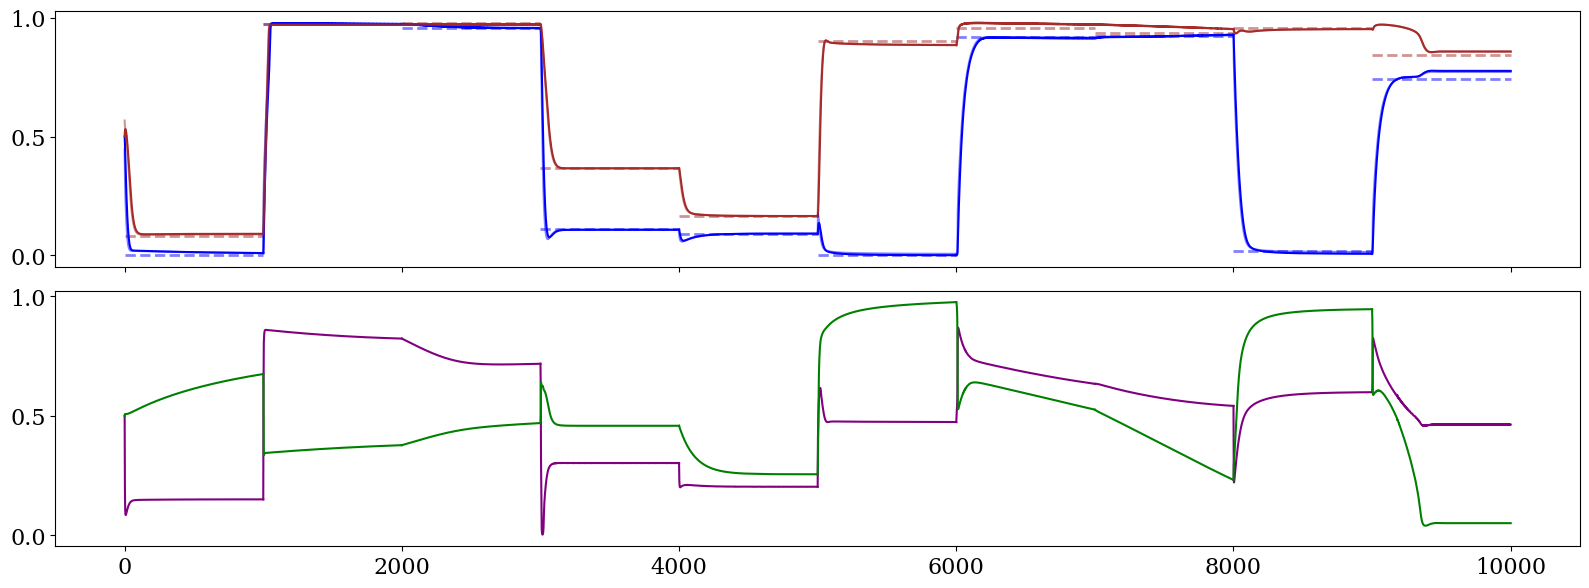

In [15]:
fig, axs = plt.subplots(2,1, figsize=(16,6),sharex =True)

axs = axs.flatten()

for idx in range(len(Ts)):
    ti = Ts[idx] + idx*t_max
    Usi = Us[idx]
    Xsi = Xs[idx]
    Xsi_target = Xs_targets[idx]
    Gsi = Gs[idx]

    ax = axs[0]
    if idx == 0:
        ax.plot(ti, Xsi[0,:],c='blue',zorder=2, label=r"$x_1$")
        ax.plot(ti, Xsi[1,:],c='brown',zorder=2,label=r"$x_2$")
        ax.plot(ti,Gsi[:,0],c='blue', alpha=0.5, label=r"$g_\theta(x,u)$")
        ax.plot(ti,Gsi[:,1],c='brown', alpha=0.5,label=r"$g_\theta(x,u)$")
    else:
        ax.plot(ti, Xsi[0,:],c='blue',zorder=2, )
        ax.plot(ti, Xsi[1,:],c='brown',zorder=2,)
        ax.plot(ti,Gsi[:,0],c='blue', alpha=0.5)
        ax.plot(ti,Gsi[:,1],c='brown', alpha=0.5)

    ax.hlines(
        Xsi_target[0],
        xmin=ti[0],
        xmax=ti[-1],
        color='blue',
        alpha=0.5,
        linestyle='--',
        zorder=1,
        lw=2
    )

    ax.hlines(
        Xsi_target[1],
        xmin=ti[0],
        xmax=ti[-1],
        color='brown',
        alpha=0.5,
        linestyle='--',
        zorder=1,
        lw=2
    )
    # ax.legend(loc='upper right', fontsize=15)

    #control
    ax = axs[1]
    labs = [r"$p$",r"$v$",  r'$\beta$', r'$\gamma$']
    colors = ["purple", "green", "green",'orange']

    for in_idx, u in enumerate(Usi):
        if idx==0:
            ax.plot(ti,u,c=colors[in_idx],label=labs[in_idx])
        else:
            ax.plot(ti,u,c=colors[in_idx],)
        # print(u[-1])|
        # print()
    # ax.legend(loc='upper right', fontsize=15)

for ax in axs:
    
    # ax.set_xticks([0,1,2,3,4,5])
    ax.set_yticks([0,0.5,1])
    ax.tick_params(axis='both', which='major', labelsize=16, )
    # ax.grid(True)


plt.tight_layout()
plt.show()


    

# Stochastic Targets

In [16]:
# in house sde solver
def itoint(drift_func, diff_func, y0, t_span, dW):
    """
    A simple Euler-Maruyama solver that accepts pre-generated noise.
    
    Args:
        drift_func: Function f(y, t) returning (d,)
        diff_func:  Function G(y, t) returning (d, m)
        y0:         Initial state (d,)
        t_span:     Time array (N,)
        dW:         Pre-calculated noise increments (N-1, m)
    
    Returns:
        Solution array of shape (N, d)
    """
    N = len(t_span)
    d = len(y0)
    
    # Pre-allocate solution array
    ys = np.zeros((N, d))
    ys[0] = y0
    
    curr_y = y0.copy()
    
    for i in range(N - 1):
        t = t_span[i]
        dt = t_span[i+1] - t
        
        # Get the specific noise increment for this step
        dw_step = dW[i]  # Shape (2,)
        
        # Evaluate dynamics
        f = drift_func(curr_y, t)   # Shape (6,)
        G = diff_func(curr_y, t)    # Shape (6, 2)
        
        # Euler-Maruyama Step: y += f*dt + G*dW
        # matrix multiplication: (6,2) @ (2,) -> (6,)
        diffusion_step = G @ dw_step 
        
        curr_y = curr_y + f * dt + diffusion_step
        curr_y[:2] = np.maximum(curr_y[:2], 0)
        ys[i+1] = curr_y
        
    return ys

In [ ]:
seed = 67
np.random.seed(seed)
rng = np.random.default_rng(seed=seed)

torch.manual_seed(seed)

torch.use_deterministic_algorithms(True)


n_targets = 10

t=np.linspace(0,1000,501)

x_targets = []
for idx in range(n_targets):
    xu = rng.uniform(0,1,size=4)

    sol = sp_solve_ivp(
        two_tank_system,
        t_span = [0,t[-1]],
        y0 = xu[:2],
        t_eval = t,
        args = (xu[2:],)
    )
    x_targets.append(sol.y[:,-1])


t_max = 500
n_colloc = 1001
eta=1e-1
k=10
scale = 0.01

t_span = np.linspace(0,t_max, n_colloc)
dt = t_span[1] - t_span[0]


xu0 = np.array([0.5,0.5,0.5,0.5])


Ts = []
Xs = []
Us = []
Xs_targets = []


noise_rng = np.random.default_rng(seed=seed)

for x_target in tqdm(x_targets):
    drift_term = make_drift(x_target,eta,k)
    diffusion_term = make_diffusion(scale)
    dW = noise_rng.normal(loc=0.0, scale=np.sqrt(dt), size=(n_colloc-1, 2))

    sto_sol = itoint(drift_term,diffusion_term,xu0,t_span,dW=dW)
    X = sto_sol[:,:2]
    U = sto_sol[:,2:]
    xu0 = sto_sol[-1]

    Ts.append(t_span)
    Xs.append(X)
    Us.append(U)
    Xs_targets.append(x_target)

Gs = []
for i in tqdm(range(len(Us))):
    ui = Us[i]
    xi=Xs[i]

    xi_tensor = torch.tensor(xi,dtype=torch.float32)
    ui_tensor = torch.tensor(ui, dtype=torch.float32)
    with torch.no_grad():
        gi = g(xi_tensor, ui_tensor)
    
    Gs.append(gi)
    
T_tot = np.linspace(0,t_max*n_targets,n_colloc*n_targets)
G_tot = np.concatenate(Gs)


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

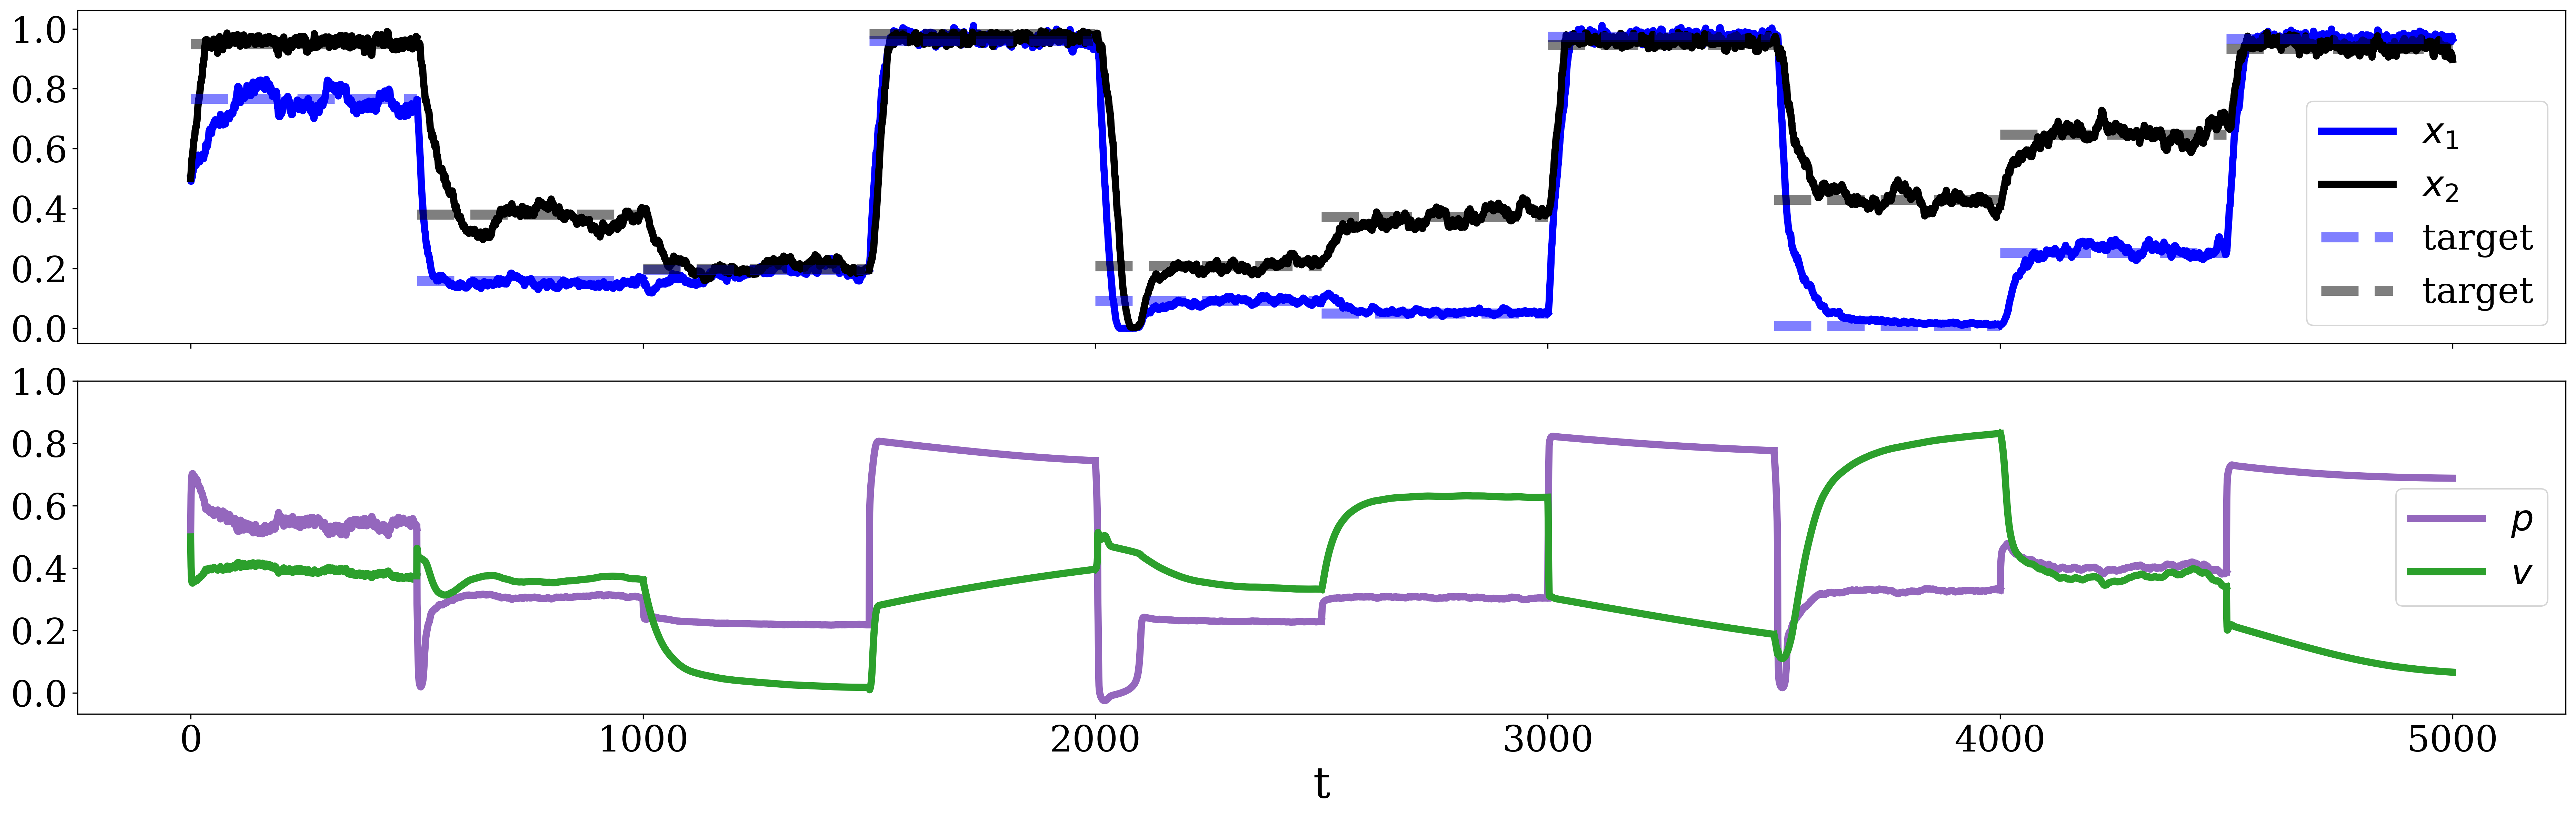

In [ ]:
lw=5

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(2.5*n_targets, 8),sharex=True,dpi=300)

for idx in range(len(Ts)):
    ti = Ts[idx] + idx*t_max
    Usi = Us[idx]
    Xsi = Xs[idx]
    Xsi_target = Xs_targets[idx]

    tank1_label = None
    tank2_label = None

    tar1_label = None
    tar2_label = None

    if idx == 0:
        tank1_label = r"$x_1$"
        tank2_label = r"$x_2$"

        tar1_label="target"
        tar2_label="target"


    ax1.plot(ti, Xsi[:,0],c='blue',lw=lw,label=tank1_label,zorder=2)
    ax1.plot(ti, Xsi[:,1],c='black',lw=lw,label=tank2_label)
    ax1.hlines(
        Xsi_target[0],
        xmin=ti[0],
        xmax=ti[-1],
        color='blue',
        linestyle='--',
        alpha=0.5,
        lw=lw+2,
        label=tar1_label
        )
    ax1.hlines(
        Xsi_target[1],
        xmin=ti[0],
        xmax=ti[-1],
        color='black',
        linestyle='--', 
        alpha=0.5,
        lw=lw+2,
        label=tar2_label
    )

    ax1.legend(fontsize=25)

    p_label=None
    v_label = None
    if idx ==0:
        p_label = r"$p$"
        v_label = r"$v$"


    ax2.plot(ti,Usi[:,0],c='tab:purple',lw=lw,label=p_label)
    ax2.plot(ti,Usi[:,1],c='tab:green',lw=lw,label=v_label)

    ax2.set_xlabel("t",size=30,)

    ax2.legend(fontsize=25,loc = 'right')

for ax in [ax1, ax2]:
    ax.tick_params(axis='both', which='major', labelsize=25)
    ax.tick_params(axis='both', which='minor', labelsize=22)
    ax.set_yticks([0,0.2,0.4,0.6,0.8,1])

ax1.legend(fontsize=25)
plt.tight_layout()
plt.savefig("mixing-tanks-feedback-control.png")
plt.show()



# Multiple seeds

In [25]:
Xs = []
Xs_targets = []
errs = []
vars = []
stds = []

settling_ratio = 0.2 # Look at last 20% of the trajectory
n_colloc = 1001
t_max = 500
eta=1e-1
k=10
t_span = np.linspace(0,t_max,n_colloc)
scale = 0.01
dt = t_span[1]-t_span[0]


t = np.linspace(0,1000,501)
seeds = [i for i in range(100)]

for seed in tqdm(seeds,unit="trial"):
    # print("Seed:", seed)
    rng = np.random.default_rng(seed)
    noise_rng = np.random.default_rng(seed)
    xu0 = np.array([0.5,0.5,0.5,0.5])


    for idx in range(n_targets,):
        # print("case:", idx)
        xu = rng.uniform(0,1,size=4)

        sol = sp_solve_ivp(
            two_tank_system,
            t_span = [0,t[-1]],
            y0 = xu[:2],
            t_eval = t,
            args = (xu[2:],)
        )
        x_target = sol.y[:,-1]
        
        drift_term = make_drift(x_target,eta,k)
        diffusion_term = make_diffusion(scale)
        dW = noise_rng.normal(loc=0.0, scale=np.sqrt(dt), size=(n_colloc-1, 2))

        sto_sol = itoint(drift_term,diffusion_term,xu0,t_span,dW=dW)
        X = sto_sol[:,:2]
        U = sto_sol[:,2:]
        xu0 = sto_sol[-1]

        # Ts.append(t_span)
        Xs.append(X)
        # Us.append(U)
        Xs_targets.append(x_target)

        # get error and var
        n_steps = len(X)
        start_idx = int(n_steps * (1 - settling_ratio))
        steady_state = X[start_idx:,:]

        diff = np.abs(steady_state - x_target)
        err = np.linalg.norm(diff, axis=0) / np.sqrt(len(steady_state))
        var = np.var(diff,axis=0)
        stds.append(np.std(steady_state,axis=0))

        errs.append(err)
        vars.append(var)
        
    print(f"running mean: {np.mean(errs)}")

errs = np.array(errs)
vars = np.array(vars)
stds = np.array(stds)
Xs_targets = np.array(Xs_targets)

  0%|          | 0/100 [00:00<?, ?trial/s]

running mean: 0.01682030700107896
running mean: 0.01924856776418225
running mean: 0.019159570203620156
running mean: 0.018648645916678183
running mean: 0.018648738270780944
running mean: 0.019668420913494387
running mean: 0.01890633271872437
running mean: 0.0186586368441006
running mean: 0.018609920775569378
running mean: 0.018734517963178578
running mean: 0.01806671388116762
running mean: 0.017955801337826333
running mean: 0.017854226162810252
running mean: 0.01825838929168825
running mean: 0.01880337606954165
running mean: 0.0183889772503194
running mean: 0.01838101432147224
running mean: 0.018384389662667422
running mean: 0.018372802721223973
running mean: 0.018220843193972703
running mean: 0.017926661277271556
running mean: 0.018080819691370723
running mean: 0.017982710641412807
running mean: 0.01793390280923134
running mean: 0.01785831028753144
running mean: 0.017765553430343837
running mean: 0.017711048209479226
running mean: 0.017557856771498705
running mean: 0.01745254944573849

In [26]:
np.mean(errs,axis=0), np.var(errs,axis=0), np.mean(vars,axis=0)

(array([0.01535596, 0.01822345]),
 array([0.00019096, 0.00017625]),
 array([9.82412230e-05, 9.46569257e-05]))

In [27]:
np.count_nonzero(errs < 1*0.05,axis=0)/ len(errs)

array([0.969, 0.976])

In [30]:
np.count_nonzero(errs < 1*0.02,axis=0)/ len(errs)

array([0.783, 0.698])

In [3]:
import numpy as np
np.sqrt(0.00019096), np.sqrt(0.00017625)

(0.01381882773609976, 0.013275918047351754)

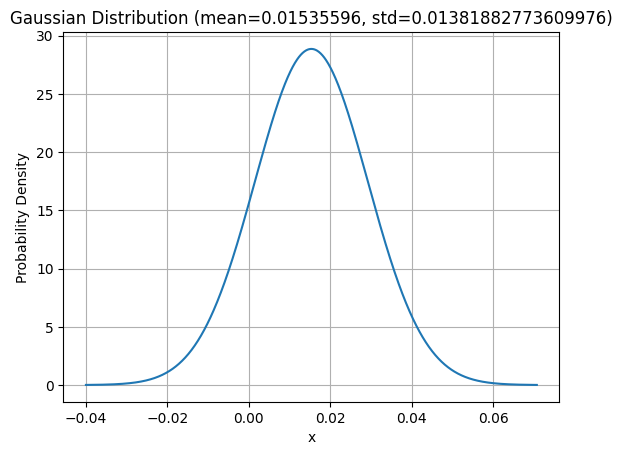

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_gaussian(mean, std, num_points=1000, num_std=4):
    x = np.linspace(mean - num_std*std, mean + num_std*std, num_points)
    y = (1/(std * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)

    plt.figure()
    plt.plot(x, y)
    plt.title(f"Gaussian Distribution (mean={mean}, std={std})")
    plt.xlabel("x")
    plt.ylabel("Probability Density")
    plt.grid(True)P
    plt.show()

# Example usage:
plot_gaussian(mean=0.01535596, std=0.01381882773609976)
